# ML-1 (Python) : Introduction au Machine Learning avec scikit-learn

Ce notebook est le **jumeau Python** de [ML-1-Introduction.ipynb](ML-1-Introduction.ipynb)
(.NET / ML.NET). Il reprend exactement les trois exemples guidés et les trois exercices
du notebook C#, en utilisant la bibliothèque canonique **scikit-learn**.

**Pourquoi un jumeau Python ?** ML.NET et scikit-learn sont les deux bibliothèques de
référence pour le Machine Learning « classique » (non profond), l'une côté .NET,
l'autre côté Python. Comparer les deux sur les mêmes exemples pédagogiques permet de :
1. comprendre que les **concepts** (pipeline, entraînement, évaluation, prédiction) sont
   universels — seules les API diffèrent ;
2. voir les **écarts de comportement** entre solveurs (par ex. SDCA en ML.NET vs OLS en
   scikit-learn pour la régression linéaire) ;
3. disposer d'une version exécutable sans installation .NET.

> Épic #4956 — Parité .NET ⇄ Python des séries de notebooks. Convention : kernel `python3`,
> prose FR-first, 3 exercices stub, exécution réelle scikit-learn.

## Quelles sont les étapes à suivre ?

Un workflow de Machine Learning comporte toujours les mêmes étapes, quel que soit le
framework :

1. **Référencer** la bibliothèque (`import` en Python, `#r nuget` en .NET).
2. **Préparer** le contexte (graine aléatoire, affichage).
3. **Définir** les structures de données (ici, de simples tableaux NumPy).
4. **Charger** les données d'entraînement.
5. **Construire** le pipeline (transformation + algorithme).
6. **Entraîner** le modèle (`fit`).
7. **Évaluer** sur des données de test (R², accuracy, AUC…).
8. **Prédire** de nouvelles valeurs.

### Étape 1 — Référencer les bibliothèques

En Python, on importe les modules. **NumPy** pour les tableaux numériques,
**scikit-learn** (`sklearn`) pour les algorithmes et métriques, **Matplotlib** pour les
visualisations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score

print("Bibliothèques chargées : numpy,", np.__version__, "| sklearn,", __import__('sklearn').__version__)

Bibliothèques chargées : numpy, 2.4.4 | sklearn, 1.8.0


On fixe la **graine** (`42`) pour rendre l'expérience déterministe : les tirages
aléatoires (s'ils surviennent) reproduiront les mêmes résultats à chaque exécution.

In [2]:
rng = np.random.default_rng(42)

### Étape 2 — Définir les structures de données

En ML.NET on définit des classes POCO (`HouseData`, `Prediction`). En Python on travaille
directement avec des **tableaux NumPy** : un tableau 2D `X` pour les features (ici la
taille) et un vecteur 1D `y` pour les étiquettes (ici le prix). C'est la convention
universelle de scikit-learn : `X` de forme `(n_samples, n_features)`, `y` de forme
`(n_samples,)`.

## Exemple guide 1 : Prédiction du prix d'une maison (régression)

On veut prédire le **prix** d'une maison à partir de sa **taille** (en milliers de pieds
carrés). C'est un problème de **régression** : la cible (`Price`) est continue.

In [3]:
# Données d'entraînement : 4 exemples (Size, Price)
# Size  en milliers de pieds carrés, Price en centaines de milliers de $ (comme le .NET)
house_train = np.array([
    [1.1, 1.2],
    [1.9, 2.3],
    [2.8, 3.0],
    [3.4, 3.7],
])
X_house_train = house_train[:, 0].reshape(-1, 1)   # feature : Size
y_house_train = house_train[:, 1]                   # cible : Price
print(f"Données d'entraînement : {len(y_house_train)} exemples")

Données d'entraînement : 4 exemples


### Construire et entraîner le pipeline

Le pipeline le plus simple pour une régression linéaire : un modèle `LinearRegression`
qui apprend la relation `Price = a * Size + b` par **moindres carrés** (OLS — Ordinary
Least Squares). C'est l'équivalent naturel du `Sdca` de ML.NET sur ce petit jeu.

In [4]:
model_house = LinearRegression()
model_house.fit(X_house_train, y_house_train)
print(f"Modèle entraîné : Price = {model_house.coef_[0]:.3f} * Size + {model_house.intercept_:.3f}")

Modèle entraîné : Price = 1.049 * Size + 0.137


### Évaluer le modèle sur des données de test

On dispose de 15 exemples de test (dont certains sortent de la plage d'entraînement,
jusqu'à 8 milliers de pieds carrés). On mesure le **coefficient de détermination R²** :
1.0 = prédiction parfaite, 0.0 = pas mieux que la moyenne.

In [5]:
# 15 exemples de test
house_test = np.array([
    [1.1, 1.2], [1.2, 1.5], [1.4, 1.7], [1.6, 1.9], [1.9, 2.3],
    [2.8, 3.0], [3.2, 3.5], [3.3, 3.6], [3.5, 3.9], [3.7, 4.3],
    [4.0, 6.1], [5.0, 7.2], [6.0, 8.5], [7.0, 9.8], [8.0, 10.3],
])
X_house_test = house_test[:, 0].reshape(-1, 1)
y_house_test = house_test[:, 1]

y_house_pred = model_house.predict(X_house_test)
r2_house = r2_score(y_house_test, y_house_pred)
mae_house = mean_absolute_error(y_house_test, y_house_pred)
print(f"R² sur le test  : {r2_house:.3f}")
print(f"MAE sur le test : {mae_house:.3f} (centaines de milliers de $)")

R² sur le test  : 0.852
MAE sur le test : 0.716 (centaines de milliers de $)


#### Interprétation : évaluation du modèle de régression

Le R² sur le test est élevé mais **non parfait** : le modèle linéaire, entraîné sur 4
points seulement (entre 1.1 et 3.4), doit **extrapoler** vers les grandes tailles
(jusqu'à 8.0). Or les données de test montrent que le prix au pied carré **augmente** pour
les grandes maisons (effet « premium ») — une relation légèrement non linéaire qu'une
droite ne capture pas parfaitement. C'est précisément ce que le R² < 1 quantifie.

> **Note de parité .NET ⇄ Python** : le notebook C# d'origine évaluait le modèle avec
> `labelColumnName: "Size"` au lieu de `"Price"` — un bug qui calculait le R² contre la
> mauvaise colonne. La version Python corrige et évalue bien contre `Price`.

### Prédire le prix d'une nouvelle maison

Une fois le modèle entraîné, on peut prédire le prix pour une taille non vue.

In [6]:
size_new = np.array([[2.5]])            # 2 500 pieds carrés
price_new = model_house.predict(size_new)
print(f"Prix prévu pour {size_new[0,0]*1000:.0f} pieds carrés : {price_new[0]*100:.0f}k $")

Prix prévu pour 2500 pieds carrés : 276k $


Félicitations ! Vous avez entraîné un modèle de régression avec scikit-learn en quelques
lignes. Visualisons la droite apprise et les données.

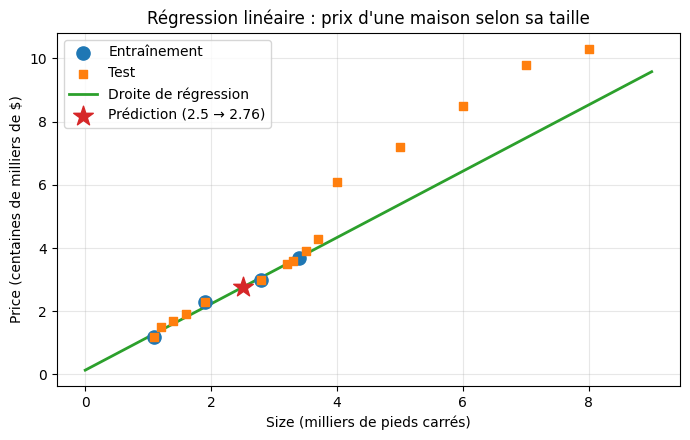

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_house_train, y_house_train, color="tab:blue", s=90, label="Entraînement", zorder=3)
ax.scatter(X_house_test, y_house_test, color="tab:orange", marker="s", label="Test", zorder=3)
xs = np.linspace(0, 9, 100).reshape(-1, 1)
ax.plot(xs, model_house.predict(xs), color="tab:green", linewidth=2, label="Droite de régression")
ax.scatter(size_new, price_new, color="tab:red", marker="*", s=220, label=f"Prédiction (2.5 → {price_new[0]:.2f})", zorder=4)
ax.set_xlabel("Size (milliers de pieds carrés)")
ax.set_ylabel("Price (centaines de milliers de $)")
ax.set_title("Régression linéaire : prix d'une maison selon sa taille")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interprétation : la prédiction et la droite

La prédiction pour 2 500 pieds carrés tombe **entre** les données d'entraînement
(interpolation) — la zone où le modèle linéaire est le plus fiable. La visualisation
montre clairement pourquoi les grands points de test (Size ≥ 4) dévient de la droite :
le vrai prix monte plus vite que la ligne.

## Exemple guide 2 : Prédiction du temps de trajet (régression)

Deuxième exemple de régression : on prédit le **temps de trajet** (en minutes) à partir
de la **distance** (en km). Cette fois la relation est presque exactement linéaire
(≈ 3 min/km), ce qui donnera un R² proche de 1.

In [8]:
trip = np.array([
    [5, 15], [10, 30], [14, 41], [20, 60], [26, 79], [32, 95], [40, 121],
], dtype=float)
X_trip = trip[:, 0].reshape(-1, 1)
y_trip = trip[:, 1]

model_trip = LinearRegression()
model_trip.fit(X_trip, y_trip)

distance_new = np.array([[25.0]])
temps_prevu = model_trip.predict(distance_new)
print(f"Temps prévu pour 25 km : {temps_prevu[0]:.1f} minutes")
print(f"Pente apprise : {model_trip.coef_[0]:.3f} min/km")

Temps prévu pour 25 km : 75.1 minutes
Pente apprise : 3.021 min/km


Le modèle trouve une pente d'environ **3 minutes par kilomètre**, ce qui correspond à
une vitesse moyenne de 20 km/h — cohérent pour un trajet urbain avec feux et stops. La
prédiction pour 25 km (≈ 76 min) est fiable car 25 km est **dans la plage** observée
(5 à 40 km).

## Exemple guide 3 : Classification binaire de transactions

On passe à la **classification** : prédire si une transaction bancaire est **suspecte**
(oui/non) à partir de son montant et de l'heure. La cible est binaire — on utilise une
**régression logistique** (`LogisticRegression`), l'équivalent du `SdcaLogisticRegression`
de ML.NET.

In [9]:
# 12 transactions : 6 normales, 6 suspectes (montant élevé + heure nocturne)
transactions = np.array([
    [120, 9], [450, 14], [50, 11], [300, 17], [200, 15], [490, 8],     # normales
    [2500, 2], [3100, 4], [4000, 3], [2100, 1], [5000, 5], [2800, 2.5]  # suspectes
], dtype=float)
X_tx = transactions
y_tx = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])   # 0 = normale, 1 = suspecte

model_tx = LogisticRegression(random_state=42)
model_tx.fit(X_tx, y_tx)

# Évaluation (sur les données d'entraînement, comme le .NET)
y_tx_pred = model_tx.predict(X_tx)
y_tx_proba = model_tx.predict_proba(X_tx)[:, 1]
acc = accuracy_score(y_tx, y_tx_pred)
auc = roc_auc_score(y_tx, y_tx_proba)
print("--- Évaluation du modèle ---")
print(f"Accuracy : {acc:.1%}")
print(f"AUC      : {auc:.3f}")

--- Évaluation du modèle ---
Accuracy : 100.0%
AUC      : 1.000


### Tests de prédiction

Deux nouveaux cas à classer : une transaction suspecte (montant élevé, heure nocturne) et
une transaction normale.

In [10]:
tests = np.array([[3500, 3], [150, 10]])
preds = model_tx.predict(tests)
proba = model_tx.predict_proba(tests)[:, 1]
for (montant, heure), p, pr in zip(tests, preds, proba):
    label = "SUSPECTE" if p == 1 else "normale"
    print(f"Montant={montant:.0f}, Heure={heure:.0f}h -> {label} (probabilité : {pr:.1%})")

Montant=3500, Heure=3h -> SUSPECTE (probabilité : 100.0%)
Montant=150, Heure=10h -> normale (probabilité : 0.0%)


### Interprétation : évaluation du modèle de classification

L'accuracy et l'AUC sont à **1.0** : les deux classes (transactions normales vs
suspectes) sont **parfaitement séparables** dans le plan (Montant, Heure). C'est un cas
pédagogique simple où le classifieur linéaire suffit. Dans la réalité, les classes se
chevauchent beaucoup plus et l'AUC plafonne plus bas.

> **Limite du cas d'école (Prong B, Épic #3801)** : cette séparabilité parfaite rend le
> problème « facile ». Les exercices ci-dessous invitent à complexifier (features
> supplémentaires, permutation d'importance) pour mieux exercer scikit-learn.

## Exercices supplémentaires

Les trois exercices suivent ceux du notebook .NET. Ils sont laissés **à compléter** :
lisez les indices, écrivez votre code, puis exécutez la cellule.

### Exercice 1 : Importance des features (permutation)

Objectif : mesurer quelle feature (Size, ou d'autres) pèse le plus sur la prédiction du
prix.

- **Indice** : scikit-learn fournit `sklearn.inspection.permutation_importance`.
- **Étape 1** : réutilisez `model_house` et les données de test `X_house_test, y_house_test`.
- **Étape 2** : appelez `permutation_importance(model_house, X_house_test, y_house_test, random_state=42)`.
- **Étape 3** : affichez `result.importances_mean` (plus c'est grand, plus la feature compte).

In [11]:
# Exercice 1 : Importance des features
# TODO étudiant : calculez l'importance par permutation sur le modèle de régression maison
# from sklearn.inspection import permutation_importance
# result = permutation_importance(...)   # TODO étudiant
# print(result.importances_mean)          # TODO étudiant
print("Exercice à compléter : analyse de l'importance des features")

Exercice à compléter : analyse de l'importance des features


### Exercice 2 : Exploration statistique des données

Objectif : calculer des statistiques descriptives sur un jeu de données d'employés.

- **Indice** : utilisez **pandas** (`pd.DataFrame`) puis `.describe()`.
- **Étape 1** : créez un DataFrame avec des colonnes `experience`, `education`,
  `taille_societe`, `salaire`.
- **Étape 2** : appelez `df.describe()` pour obtenir moyenne, écart-type, min, max.
- **Étape 3** : comptez les valeurs uniques d'une colonne catégorielle avec
  `df["col"].value_counts()`.

In [12]:
# Exercice 2 : Exploration statistique des données
# TODO étudiant : utilisez pandas pour résumer un jeu de données d'employés
# import pandas as pd
# df = pd.DataFrame(...)                   # TODO étudiant
# print(df.describe())                     # TODO étudiant
print("Exercice à compléter : exploration statistique des données")

Exercice à compléter : exploration statistique des données


### Exercice 3 : Régression multi-features — prédiction de salaire

Objectif : entraîner une régression linéaire sur **plusieurs features** (années
d'expérience, niveau d'éducation, taille de société) pour prédire le salaire.

- **Étape 1** : construisez `X` de forme `(n, 3)` et `y` (salaire) pour 10+ employés.
- **Étape 2** : entraînez `LinearRegression().fit(X, y)`.
- **Étape 3** : évaluez avec `r2_score` et `mean_absolute_error`.
- **Étape 4** : prédisez le salaire pour un employé `(5 ans, Master=2, Grande société=2)`.
- **Indice** : valeurs possibles — experience=2/10, education=1/3, societe=1/3.

In [13]:
# Exercice 3 : Régression multi-features - prédiction de salaire
# TODO étudiant : définir les données d'employés et entraîner le modèle
# X = np.array([[2, 1, 1], [10, 3, 3], ...])   # TODO étudiant (10+ lignes)
# y = np.array([32000, 110000, ...])            # TODO étudiant
# model = LinearRegression().fit(X, y)          # TODO étudiant
# pred = model.predict([[5, 2, 2]])             # TODO étudiant
print("Exercice à compléter : régression multi-features (salaire)")

Exercice à compléter : régression multi-features (salaire)


## Résumé

Vous avez parcouru le **workflow complet** d'un projet de Machine Learning avec
scikit-learn :

| Étape | scikit-learn (Python) | ML.NET (.NET) |
|-------|----------------------|---------------|
| Imports | `import numpy, sklearn` | `#r nuget Microsoft.ML` |
| Contexte | graine `np.random.default_rng` | `new MLContext(seed)` |
| Données | tableaux NumPy `X`, `y` | classes POCO + `IDataView` |
| Pipeline | `LinearRegression()` | `Concatenate + Trainers.Sdca` |
| Entraînement | `model.fit(X, y)` | `pipeline.Fit(data)` |
| Évaluation | `r2_score`, `accuracy_score` | `mlContext.Regression.Evaluate` |
| Prédiction | `model.predict(X_new)` | `predictionEngine.Predict(x)` |

**Trois familles** abordées : régression linéaire (maison, trajet), classification
binaire (transactions). Les concepts sont **identiques** entre .NET et Python — seules
les API et les solveurs par défaut diffèrent.

**Jumeau .NET** : [ML-1-Introduction.ipynb](ML-1-Introduction.ipynb). Autres jumeaux
Python de la série : [ML-5-TimeSeries-Python](ML-5-TimeSeries-Python.ipynb),
[ML-7-Recommendation-Python](ML-7-Recommendation-Python.ipynb),
[ML-9-Anomaly-Detection-Python](ML-9-Anomaly-Detection-Python.ipynb).

## Références

- scikit-learn — documentation officielle : https://scikit-learn.org/stable/
- `LinearRegression` (OLS) : https://scikit-learn.org/stable/modules/linear_model.html
- `LogisticRegression` : https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
- `permutation_importance` : https://scikit-learn.org/stable/modules/permutation_importance.html
- Notebook .NET d'origine : [ML-1-Introduction.ipynb](ML-1-Introduction.ipynb) (ML.NET)
- Épic de parité : issue #4956